# Линейные модели

В рамках данного проекта ты реализуешь и обучишь линейную регрессию и логистическую регрессию — два фундаментальных алгоритма машинного обучения для решения задач регрессии и классификации. Начав с аналитического решения методом наименьших квадратов, ты перейдёшь к реализации алгоритма градиентного спуска для оптимизации параметров моделей. В процессе работы ты исследуешь такие важные аспекты, как регуляризация для борьбы с переобучением, стандартизация признаков и интерпретируемость коэффициентов моделей. Эти знания помогут тебе глубже понять принципы работы линейных моделей и научиться применять их для решения практических задач.

In [1]:
import numpy as np
from typing import Tuple

### Линейная регрессия
Линейная регрессия — один из самых простых и важных алгоритмов машинного обучения. Её идея — описать зависимость целевой переменной от признаков линейной функцией и подобрать параметры так, чтобы предсказания были максимально близки к наблюдениям.

Пусть у нас есть набор данных из $N$ объектов: для каждого объекта известны признаки $\mathbf{x}_i$ и целевое значение $y_i$. Мы хотим найти такую линейную функцию:

$$y = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

где:
- $\mathbf{w} = (w_1, w_2, \ldots, w_n)^T$ — вектор весов (параметров модели);
- $b$ — свободный член (bias);
- $\mathbf{x} = (x_1, x_2, \ldots, x_n)^T$ — вектор признаков объекта.

![Бриллианты](../misc/images/diamonds.png)

Чтобы быстро перейти от теории к практике, возьмём реальный датасет о бриллиантах. Один из ключевых факторов цены — каратность. Для начала предположим простую модель с одним признаком:

$$y = w \cdot x + b + \varepsilon$$

где:
- $y$ — цена бриллианта;
- $x$ — каратность;
- $b$ — базовая цена (свободный член);
- $w$ — «цена» одного карата (коэффициент при признаке);
- $\varepsilon$ — шум (то, что модель не объясняет).

Чтобы по каратности предсказывать цену для новых камней, нужно оценить параметры $w$ и $b$ по историческим данным.

Один из способов — аналитическое решение через метод наименьших квадратов (МНК). В матричной записи это приводит к «нормальному уравнению»:

$$X^T (y - X\hat{w}) = 0$$
$$X^T X\hat{w} = {X}^T y$$
Если $X^T X$ обратима, то:
$$\hat{w} = (X^T X)^{-1} X^T y$$

#### Зачем начинать с аналитического решения?

Прежде чем перейти к градиентному спуску, полезно увидеть, что для простого случая линейной регрессии существует
**точное решение в замкнутой форме**. Это позволяет:
- получить эталонные значения параметров $w$ и $b$, с которыми потом можно сравнить результат градиентного спуска;
- убедиться, что ты правильно понимаешь постановку задачи и формат данных;
- прочувствовать, почему при большом числе признаков аналитический подход становится непрактичным.

## Задание 1. Аналитическое решение

В этом задании тебе требуется построить линейную модель для предсказания стоимости бриллианта на основе его каратности с помощью метода наименьших квадратов (МНК). Ты реализуешь аналитическое решение «вручную», используя матричные операции, а затем проверишь правильность своей реализации, сравнив результаты с библиотекой `sklearn`.

1. **Подготовка данных:**
   - Загрузи датасет из файла `datasets/diamonds.csv`.
   - Возьми один признак: каратность (`carat`) и целевую переменную: цену (`price`).
   - Сформируй матрицу признаков `X` размера $N \times 1$ и вектор ответов `y` размера $N$.

2. **Реализация аналитического решения (МНК):**
   - Добавь к `X` столбец единиц, чтобы учитывать свободный член $b$.
   - Вычисли $\hat{w}$ по формуле: $\hat{w} = (X^T X)^{-1} X^T y$.
   - Выведи полученные параметры модели: `b_v1` (свободный член) и `w_v1` (коэффициент при каратности).
   - Интерпретируй результаты: что означает полученное значение $w$? Какую цену будет иметь бриллиант с нулевой каратностью (параметр $b$)?

3. **Сравнение с `sklearn`:**
   - Обучи `LinearRegression` из `sklearn.linear_model` на тех же `X` и `y`.
   - Выведи полученные параметры модели: `b_v2` (свободный член) и `w_v2` (коэффициент при каратности).
   - Сравни коэффициенты: они должны совпасть или быть очень близкими (например, через `np.allclose`).

4. **Оценка качества и визуализация:**
   - Посчитай MAE (Mean Absolute Error, среднюю абсолютную ошибку) для аналитического решения.
   - Посчитай MAE для решения через `sklearn`.
   - Построй график: точки (реальные данные) и прямая регрессии (предсказания модели).

In [2]:
import pandas as pd

df = pd.read_csv('diamonds.csv')
df['b'] = [1] * len(df)

In [3]:
X = df[['carat','b']]
y = df['price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42, 
    test_size=0.2,
    shuffle=True,
)

In [4]:
x = X_train.values
w = np.linalg.inv(x.T @ x) @ x.T @ y_train

In [5]:
w_v1, b_v1 = w
print(w_v1, b_v1)

7768.910490360817 -2261.9117456492118


w - это отношение каратности и цены. Будет иметь цену (7768)

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
w_v2, b_v2 = model.coef_[0], model.intercept_

In [7]:
w_v2, b_v2

(np.float64(7768.910490360937), np.float64(-2261.9117456493095))

In [8]:
print(f"Коэффициенты совпадают? - {np.allclose([b_v1, w_v1], [b_v2, w_v2])}")

Коэффициенты совпадают? - True


In [9]:
pred1 = X_test @ [w_v1, b_v1]
pred2 = model.predict(X_test)

from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, pred1))
print(mean_absolute_error(y_test, pred2))

1009.5047420600886
1009.5047420601013


#### Почему аналитическое решение не используется на практике?

Ты только что получил точные параметры $w$ и $b$ одной операцией — казалось бы, задача решена. Но у формулы
$\hat{w} = (X^T X)^{-1} X^T y$ есть серьёзные ограничения:

- **Сложность вычислений**: обращение матрицы стоит $O(d^3)$, где $d$ — число признаков. При $d$ в десятки тысяч
  (текстовые или пиксельные признаки) это становится вычислительно неподъёмным.
- **Память**: нужно хранить матрицу $X^TX$ размера $d \times d$.
- **Численная нестабильность**: если признаки коррелируют, матрица $X^TX$ плохо обусловлена и обратная матрица
  даёт неточный результат.

#### Решение — градиентный спуск

Вместо того чтобы вычислять решение «за один шаг», градиентный спуск приближается к нему итеративно:
на каждой итерации мы чуть-чуть сдвигаем параметры в сторону, уменьшающую ошибку. Это масштабируется
на миллионы признаков и лежит в основе обучения нейронных сетей.

Основная идея: мы хотим минимизировать функцию потерь — среднеквадратичную ошибку (MSE):

$$
L(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

где предсказание модели:

$$
\hat{y}_i = b + w_1 x_{i1} + w_2 x_{i2} + \dots + w_d x_{id} = b + \mathbf{w}^\top \mathbf{x}_i
$$

Для минимизации функции потерь мы будем использовать её **градиент**.

Градиент — это вектор, составленный из частных производных функции.
Он показывает направление, в котором функция растёт быстрее всего.
Поэтому, чтобы двигаться к минимуму, нам нужно идти в **противоположную** сторону — против градиента.

Следовательно, обновлять параметры будем по такому правилу:

$$
b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}
$$

$$
w_j \leftarrow w_j - \alpha \cdot \frac{\partial L}{\partial w_j}, \quad j = 1, \dots, d
$$

где $\alpha$ — шаг (learning rate).

## Задание 2. Градиент функции потерь

Чтобы реализовать градиентный спуск, нужно знать, в каком направлении изменять параметры модели. Для этого требуется вычислить градиент функции потерь — вектор частных производных по каждому параметру. Градиент показывает направление наибольшего роста функции, поэтому для минимизации мы движемся в противоположном направлении.

В этом задании тебе нужно вычислить градиент функции потерь $L$ для случая одного признака ($\hat{y}_i = b + w_1 x_i$).
Найди частные производные по $b$ и $w_1$. Запиши:

$$
\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - b - w_1 x_i)
$$

$$
\frac{\partial L}{\partial w_1} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - b - w_1 x_i) x_i
$$

## Задание 3. Обновление параметров

Теперь, когда ты знаешь, как вычисляется градиент функции потерь, можно перейти к практической реализации. В этом задании ты создашь класс `Gradient`, который инкапсулирует логику работы с градиентами и обновления параметров модели. Этот класс станет основой для реализации полного алгоритма градиентного спуска в следующем задании.

Класс будет содержать методы для предсказания, вычисления ошибки и обновления параметров согласно формулам градиентного спуска, которые ты вывел в предыдущем задании.

1. **Реализация класса `Gradient`:**
   - Напиши класс `Gradient()`, который при инициализации получает два вектора: `X` (признаки) и `Y` (целевая переменная).
   - Реализуй методы класса согласно их docstrings и аннотациям типов (type hints).
   - Обрати внимание на сигнатуры методов и их возвращаемые значения: `predict` возвращает массив предсказаний, `mse` возвращает число, `update` возвращает кортеж из двух элементов.

2. **Проверка работы методов:**
   - Инициализируй класс с данными `X`, `Y` из задания 1 (признак `carat` и целевая переменная `price`).
   - Задай начальные параметры (например, `w=0`, `b=0`).
   - Вызови `predict` и `mse` для проверки корректности работы методов.
   - Вызови `update` несколько раз (2–3 итераций) и покажи, как изменяются ошибка (MSE) и параметры `w`, `b` после каждого обновления.

In [10]:
class Gradient:
    """
    Класс для работы с градиентами и обновления параметров модели.
    
    При инициализации получает два вектора: X (признаки) и Y (целевая переменная).
    """
    def __init__(self, X: np.ndarray, Y: np.ndarray) -> None:
        self.X = X
        self.Y = Y
        self.n = len(X)

    def predict(self, w: np.ndarray, b: float) -> np.ndarray:
        """
        Вычисляет прогнозные значения модели.
        
        Parameters:
        -----------
        w : array-like
            Параметры модели (веса)
        b : float
            Свободный член (bias)
            
        Returns:
        --------
        prediction : array-like
            Прогнозные значения prediction = w * X + b
        """
        pred =  w * X + b
        return pred

    def mse(self, prediction: np.ndarray) -> float:
        """
        Вычисляет среднеквадратичную ошибку.
        
        Parameters:
        -----------
        prediction : array-like
            Предсказания модели
            
        Returns:
        --------
        mse : float
            Среднеквадратичная ошибка относительно Y
        """
        return np.mean((self.Y - prediction)**2)

    def update(self, w: np.ndarray, b: float, a: float = 0.01) -> Tuple[np.ndarray, float]:
        """
        Обновляет параметры модели согласно формулам градиентного спуска.
        
        Parameters:
        -----------
        w : array-like
            Текущие параметры модели (веса)
        b : float
            Текущий свободный член (bias)
        a : float, default=0.01
            Learning rate (шаг обучения)
            
        Returns:
        --------
        w_new : array-like
            Обновленные параметры w
        b_new : float
            Обновленный свободный член b
        """
        pred = self.predict(w, b)
        error = self.Y - pred

        dl_b = - (2 / self.n) * np.sum(error)
        dl_w = - (2 / self.n) * np.sum(error * self.X)

        w_new = w - a * dl_w
        b_new = b - a * dl_b
        
        return w_new, b_new
        

In [11]:
X = df['carat']
y = df['price']

# Инициализация класса
grad = Gradient(X, y)

# Начальные параметры
w_init = np.array([0.0])  # w в виде массива (для единообразия)
b_init = 0.0

# Проверка predict и mse до обучения
initial_pred = grad.predict(w_init, b_init)
initial_mse = grad.mse(initial_pred)
print("Начальные параметры: w =", w_init, ", b =", b_init)
print("Начальный MSE:", initial_mse)

# Несколько итераций обновления
w, b = w_init, b_init
learning_rate = 0.01
for i in range(3):
    w, b = grad.update(w, b, a=learning_rate)
    pred = grad.predict(w, b)
    current_mse = grad.mse(pred)
    print(f"\nИтерация {i+1}:")
    print(f"  w = {w}, b = {b}")
    print(f"  MSE = {current_mse}")

Начальные параметры: w = [0.] , b = 0.0
Начальный MSE: 31382248.015257694

Итерация 1:
  w = [97.61740547], b = 78.65599443826474
  MSE = 29837304.246570382

Итерация 2:
  w = [192.29782226], b = 154.1810128296143
  MSE = 28395300.853477713

Итерация 3:
  w = [284.14181484], b = 226.68454549513075
  MSE = 27049242.57942541


## Задание 4. Градиентный спуск

Теперь, когда у тебя есть класс `Gradient` с методами для обновления параметров, можно реализовать полный алгоритм градиентного спуска. В этом задании ты создашь класс `GradientDescent`, который наследуется от `Gradient` и автоматизирует процесс обучения модели: итеративно обновляет параметры, отслеживает историю обучения и останавливается по заданным критериям.

Важной особенностью реализации будет адаптивный learning rate: в процессе обучения learning rate будет уменьшаться, что позволяет сначала быстро приблизиться к минимуму, а затем точно настроить параметры модели.

1. **Реализация класса `GradientDescent`:**
   - Создай класс `GradientDescent(Gradient)`, который наследует все методы из `Gradient`.
   - Реализуй метод `optimize` согласно его docstrings и аннотациям типов (type hints).
   - Метод должен итеративно обновлять `w` и `b` с помощью метода `update`.
   - **Важно:** learning rate `a` должен уменьшаться в ходе обучения по формуле: $a_t = a_0 \cdot \frac{1}{1 + \text{decay} \cdot t}$, где $a_0$ — начальный learning rate, $t$ — номер итерации, $\text{decay} = 0.01$ — коэффициент затухания.
   - Критерии остановки:
     - Превышено количество итераций `num_iterations`.
     - Изменение MSE между итерациями меньше `stopping_threshold`.
   - Метод должен вернуть словарь с ключами: `'w'`, `'b'`, `'mse'`, `'history'` (список значений MSE на каждой итерации), `'iterations'` (количество выполненных итераций).

2. **Визуализация и анализ:**
   - Обучи модель на данных `X`, `Y` с разными значениями learning rate: `[0.0000001, 0.001, 1]`.
   - Для каждого learning rate построй график зависимости MSE от номера итерации.
   - На отдельном графике визуализируй финальные линии регрессии для разных learning rate.

3. **Сравнение с аналитическим решением:**
   - Сравни полученные градиентным спуском значения с аналитическим решением из Задания 1.
   - Визуализируй оба решения на одном графике.
   - Выведи значение MSE для лучшего результата.

In [12]:
class Gradient:
    """
    Класс для работы с градиентами и обновления параметров модели.
    
    При инициализации получает два вектора: X (признаки) и Y (целевая переменная).
    """
    def __init__(self, X: np.ndarray, Y: np.ndarray) -> None:
        self.X = X
        self.Y = Y
        self.n = len(X)

    def predict(self, w: np.ndarray, b: float) -> np.ndarray:
    
        pred =  w * X + b
        return pred

    def mse(self, prediction: np.ndarray) -> float:
      
        return np.mean((self.Y - prediction)**2)

    def update(self, w: np.ndarray, b: float, a: float = 0.01) -> Tuple[np.ndarray, float]:
        
        pred = self.predict(w, b)
        error = self.Y - pred

        dl_b = - (2 / self.n) * np.sum(error)
        dl_w = - (2 / self.n) * np.sum(error * self.X)

        w_new = w - a * dl_w
        b_new = b - a * dl_b
        
        return w_new, b_new
        

In [13]:
class GradientDescent(Gradient):
    def optimize(self, w0: np.ndarray, b0: float,
                 a0: float = 0.01, decay: float = 0.01,
                 num_iterations: int = 1000,
                 stopping_threshold: float = 1e-6) -> dict:
        """
        Полный алгоритм градиентного спуска с адаптивным learning rate.

        Параметры:
        ----------
        w0 : начальный вектор весов
        b0 : начальное смещение
        a0 : начальный learning rate
        decay : коэффициент затухания learning rate
        num_iterations : максимальное число итераций
        stopping_threshold : порог изменения MSE для остановки

        Возвращает:
        ----------
        Словарь с ключами:
            'w', 'b' – итоговые параметры,
            'mse' – финальное MSE,
            'history' – список MSE на каждой итерации,
            'iterations' – число выполненных итераций
        """
        w = w0.copy()
        b = b0
        a = a0

        history = []

        for t in range(num_iterations):
            w1, b1 = self.update(w, b, a)

            pred = self.predict(w1, b1)
            if self.mse(pred) < stopping_threshold:
                break

            history.append(self.mse(self.predict(w1, b1)))

            a = a * (1 / 1 + (decay * t))

            if self.mse(self.predict(w1, b1)) <= self.mse(self.predict(w, b)):
                w = w1
                b = b1
                

        return {
            'w': w,
            'b': b,
            'mse': self.mse(self.predict(w, b)),
            'iterations': t,
            'history': history
        }

            
            


c:\Users\user\Desktop\pet\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\user\AppData\Local\Temp\ipykernel_3668\4165335921.py:29: RuntimeWarning: overflow encountered in scalar multiply
  w_new = w - a * dl_w
C:\Users\user\AppData\Local\Temp\ipykernel_3668\4165335921.py:30: RuntimeWarning: overflow encountered in scalar multiply
  b_new = b - a * dl_b


LR=1e-07: w=5764.2081, b=-592.7820, MSE=3295166.8474, итераций=1999
LR=0.001: w=7638.9694, b=-2121.5099, MSE=2402746.2478, итераций=1999
LR=1: w=0.0000, b=0.0000, MSE=31382248.0153, итераций=1999


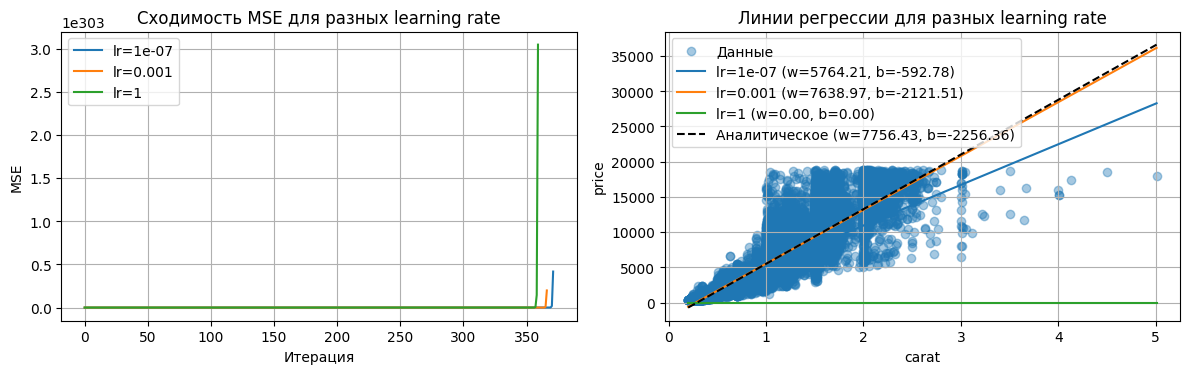


Лучший learning rate: 0.001
Параметры градиентного спуска: w=7638.969398, b=-2121.509911
Аналитические параметры:      w=7756.425618, b=-2256.360580
MSE градиентного спуска: 2402746.247803


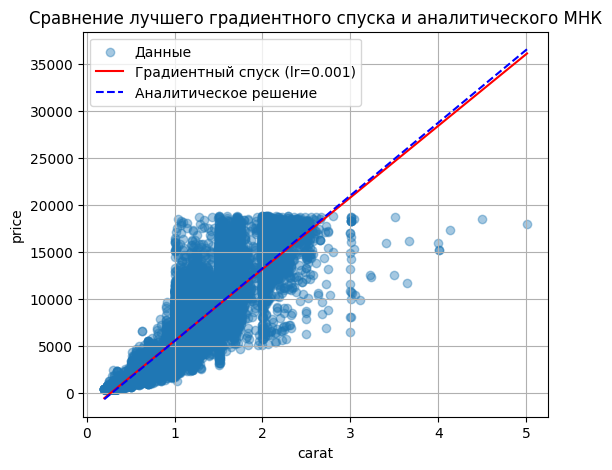

In [14]:
import matplotlib.pyplot as plt


# ------------------ Аналитическое решение (МНК) ------------------
# Для модели y = w * x + b
cov_xy = np.mean(X * y) - np.mean(X) * np.mean(y)
var_x = np.mean(X**2) - np.mean(X)**2
w_analytical = cov_xy / var_x
b_analytical = np.mean(y) - w_analytical * np.mean(X)

# ------------------ Обучение с разными learning rate ------------------
gd = GradientDescent(X, y)
learning_rates = [0.0000001, 0.001, 1]
results = {}

for lr in learning_rates:
    res = gd.optimize(w0=np.array([0.0]), b0=0.0, a0=lr,
                      decay=0.01, num_iterations=2000, stopping_threshold=1e-8)
    results[lr] = res
    print(f"LR={lr}: w={res['w'][0]:.4f}, b={res['b']:.4f}, MSE={res['mse']:.4f}, итераций={res['iterations']}")

# ------------------ График сходимости MSE ------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(results[lr]['history'], label=f'lr={lr}')
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость MSE для разных learning rate')
plt.legend()
plt.grid(True)

# ------------------ Финальные линии регрессии ------------------
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.4, label='Данные')
x_line = np.linspace(X.min(), X.max(), 100)
for lr in learning_rates:
    w_opt = results[lr]['w'][0]
    b_opt = results[lr]['b']
    plt.plot(x_line, w_opt * x_line + b_opt, label=f'lr={lr} (w={w_opt:.2f}, b={b_opt:.2f})')
# Добавим аналитическое решение
plt.plot(x_line, w_analytical * x_line + b_analytical, 'k--',
         label=f'Аналитическое (w={w_analytical:.2f}, b={b_analytical:.2f})')
plt.xlabel('carat')
plt.ylabel('price')
plt.title('Линии регрессии для разных learning rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------ Сравнение с аналитическим решением ------------------
# Выберем лучший learning rate (по минимальному MSE)
best_lr = min(results, key=lambda lr: results[lr]['mse'])
best_res = results[best_lr]
print("\nЛучший learning rate:", best_lr)
print(f"Параметры градиентного спуска: w={best_res['w'][0]:.6f}, b={best_res['b']:.6f}")
print(f"Аналитические параметры:      w={w_analytical:.6f}, b={b_analytical:.6f}")
print(f"MSE градиентного спуска: {best_res['mse']:.6f}")

# Визуализация лучшего и аналитического решения на одном графике
plt.figure(figsize=(6, 5))
plt.scatter(X, y, alpha=0.4, label='Данные')
plt.plot(x_line, best_res['w'][0] * x_line + best_res['b'], 'r-',
         label=f'Градиентный спуск (lr={best_lr})')
plt.plot(x_line, w_analytical * x_line + b_analytical, 'b--',
         label='Аналитическое решение')
plt.xlabel('carat')
plt.ylabel('price')
plt.legend()
plt.title('Сравнение лучшего градиентного спуска и аналитического МНК')
plt.grid(True)
plt.show()

## Задание 5. Используем все данные

Попробуем улучшить результат предсказания цены бриллианта, используя все доступные признаки датасета (каратность,
огранка, цвет, чистота, глубина, таблица, размеры x, y, z).

1. **Загрузи данные и подготовь целевую переменную:**
   - Загрузи датасет из файла `datasets/diamonds.csv`.
   - Выдели целевую переменную `price` (вектор `y`) и все остальные столбцы как признаки (матрица `X`).

2. **Закодируй категориальные признаки:**
   - Столбцы `cut`, `color`, `clarity` — категориальные. Примени к ним `OneHotEncoder` (или `pd.get_dummies`).
   - После кодирования проверь, что в данных не осталось строковых столбцов.

3. **Раздели данные на обучающую и тестовую выборку:**
   - Используй `train_test_split` из `sklearn.model_selection` (80% train / 20% test, `random_state=21`).

4. **Стандартизируй числовые признаки:**
   - Примени `StandardScaler`: обучи (`.fit_transform`) на тренировочных данных, примени (`.transform`) к тестовым.
   - Важно: скейлер обучается **только** на обучающей выборке, чтобы не допускать утечки данных.

5. **Обучи модель и оцени качество:**
   - Обучи `SGDRegressor` из `sklearn.linear_model` на обучающей выборке.
   - Посчитай MAE и MSE на тестовой выборке.
   - Сравни с результатом модели только по каратности из Задания 1: улучшилось ли качество?

In [15]:
df = pd.read_csv('C://Users/User/Desktop/ml3/AI_Machine_Learning_Project_3.ID_1577773-1/datasets/diamonds.csv')
X = df.drop('price', axis=1)
y = df['price']

X = pd.get_dummies(X, ['cut', 'color', 'clarity'], drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=21
)

from sklearn.preprocessing import StandardScaler

st = StandardScaler()
X_train = st.fit_transform(X_train)
X_test = st.transform(X_test)

from sklearn.linear_model import SGDRegressor

model = SGDRegressor()
model.fit(X_train, y_train)
pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

print(mean_absolute_error(y_true=y_test, y_pred=pred), mean_squared_error(y_true=y_test, y_pred=pred))
print('Улучшилось')

FileNotFoundError: [Errno 2] No such file or directory: 'C://Users/User/Desktop/ml3/AI_Machine_Learning_Project_3.ID_1577773-1/datasets/diamonds.csv'

## Задание 6. Ridge и Lasso регрессии

**Что такое регуляризация и зачем она нужна**

При обучении на многих признаках модель может «подстроиться» под шум в данных и плохо работать на новых примерах — это переобучение. Регуляризация ограничивает сложность модели, добавляя к функции потерь штраф за большие веса. Так мы заставляем модель не полагаться слишком сильно на отдельные признаки и лучше обобщать.

Два самых распространённых вида регуляризации в линейных моделях:

- **Ridge (L2-регуляризация)** добавляет штраф $\lambda \|w\|_2^2 = \lambda \sum_j w_j^2$. Все веса уменьшаются по величине, но остаются ненулевыми. Ridge устойчива к мультиколлинеарности (сильной связи между признаками) и часто улучшает качество на тесте.
- **Lasso (L1-регуляризация)** добавляет штраф $\lambda \|w\|_1 = \lambda \sum_j |w_j|$. Часть весов обнуляется — модель автоматически отбирает наиболее важные признаки. Lasso полезен для интерпретации и когда признаков много, а значимых мало.

Сила регуляризации задаётся гиперпараметром $\alpha$: чем больше $\alpha$, тем сильнее штраф и тем «проще» модель.

В этом задании ты сравнишь Ridge и Lasso с моделью без регуляризации и оценишь, насколько регуляризация помогает качеству на тех же данных про бриллианты.

1. **Обучи Ridge-модель:**
   - Используй `Ridge` из `sklearn.linear_model` с `alpha=0.01`.
   - Обучи на `X_train_scaled`, `y_train` из Задания 5.
   - Посчитай MAE и MSE на тестовой выборке.

2. **Обучи Lasso-модель:**
   - Используй `Lasso` из `sklearn.linear_model` с `alpha=0.01`.
   - Обучи на тех же данных.
   - Посчитай MAE и MSE на тестовой выборке.

3. **Сравни качество трёх моделей:**
   - Выведи MAE и MSE для SGDRegressor (Задание 5), Ridge и Lasso в одной таблице/выводе.
   - Улучшилось ли качество при использовании Ridge или Lasso? Насколько?

In [ ]:
from sklearn.linear_model import Lasso, Ridge

lasso = Lasso()
ridge = Ridge()
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

pred1 = lasso.predict(X_test)
pred2 = ridge.predict(X_test)

print(mean_absolute_error(y_true=y_test, y_pred=pred1), mean_squared_error(y_true=y_test, y_pred=pred1))
print(mean_absolute_error(y_true=y_test, y_pred=pred1), mean_squared_error(y_true=y_test, y_pred=pred1))

print('Слегка улучшилось на 9')

730.3490473893802 1221221.092538543
730.3490473893802 1221221.092538543
Слегка улучшилось на 9


### Логистическая регрессия
Кроме задачи регрессии линейные алгоритмы способны также решать задачу **классификации**.
Для этого используется **логистическая регрессия** — один из самых популярных и понятных методов бинарной классификации.

### Основные отличия от линейной регрессии

Линейная регрессия предсказывает **непрерывные значения** (любое вещественное число),
а логистическая регрессия — **вероятность принадлежности** к одному из двух классов (обычно 0 или 1).

- Выход модели — вероятность от 0 до 1.
- Функция активации — сигмоида:
  $$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$
- Функция потерь — Log Loss (бинарная кросс-энтропия).

### Как работает логистическая регрессия

1. Считаем линейную комбинацию признаков (как обычно):
   $$z = b + w_1 x_1 + w_2 x_2 + \ldots + w_d x_d$$

2. Применяем сигмоиду, чтобы получить вероятность:
   $$P(y = 1 \mid x) = \hat{y} = \frac{1}{1 + e^{-z}}$$

3. Принимаем решение по порогу (чаще всего 0.5):
   $$\hat{y} \ge 0.5 \Rightarrow \text{класс 1}, \quad \hat{y} < 0.5 \Rightarrow \text{класс 0}$$

### Функция потерь (Log Loss)

Для одного примера:

$$L = -\bigl[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \bigr]$$

Чем ближе предсказанная вероятность $\hat{y}$ к реальному классу $y$, тем меньше значение потерь.

![fashion](../misc/images/fashion.png)

## Задание 7. Разделяющая плоскость

В этом задании тебе нужно обучить модель логистической регрессии на **синтетических данных** и построить разделяющую прямую (в случае двух признаков — линию, разделяющую классы).

1. **Сгенерируй синтетические данные:**
   - Используй `make_blobs` из `sklearn.datasets`: два класса, два признака (например, `n_samples=200`, `centers=2`, `n_features=2`, зафиксируй `random_state=21`).
   - Получи матрицу признаков `X` и вектор меток `y`.

2. **Обучи модель логистической регрессии:**
   - Используй `LogisticRegression` из `sklearn.linear_model`.
   - Рекомендуемые параметры: `penalty=None` (без регуляризации), `solver="lbfgs"` или `"liblinear"`.
   - Обучи модель на полученных данных. Выведи коэффициенты `coef_` и `intercept_`.
   - Посчитай точность на этих же данных: `model.score(X, y)`.

3. **Визуализируй результаты:**
   - Построй scatter plot: точки двух классов разными цветами.
   - Нарисуй разделяющую прямую. Используй коэффициенты модели для построения линии.
   - Добавь легенду, подписи осей, заголовок, сетку.

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

X, y = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    random_state=21
)

model = LogisticRegression(
    penalty = None,
    solver = 'lbfgs',
    random_state=21
)

model.fit(X, y)

print(model.coef_, model.intercept_)
s = model.score(X, y)
print(s)


[[ 1.60563992 -0.54271774]] [-0.01421595]
1.0


c:\Users\User\Desktop\ml3\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


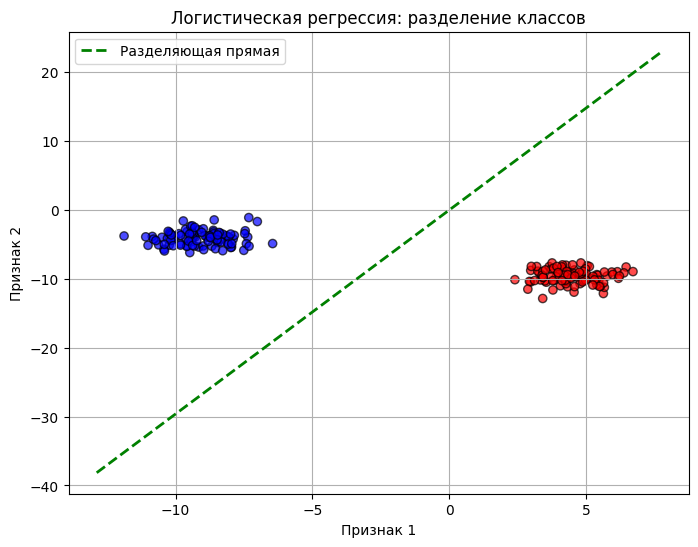

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Scatter plot точек, раскрашенных по классам
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.7)

# 2. Построение разделяющей прямой по коэффициентам модели
coef = model.coef_[0]         # w1, w2
intercept = model.intercept_[0]  # b

# Создаём сетку значений для первого признака
x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
# Уравнение прямой: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
y_vals = -(coef[0] * x_vals + intercept) / coef[1]

plt.plot(x_vals, y_vals, 'g--', linewidth=2, label='Разделяющая прямая')

# 3. Оформление
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Логистическая регрессия: разделение классов')
plt.legend()
plt.grid(True)
plt.show()

## Задание 8. Загрузка датасета Fashion-MNIST

Fashion-MNIST — датасет изображений одежды и аксессуаров (28×28 пикселей, 10 классов). Он часто используется
как замена MNIST для оценки алгоритмов классификации.

1. **Загрузи датасет Fashion-MNIST:**
   - Используй `torchvision.datasets.FashionMNIST` (PyTorch).
   - Получи обучающую и тестовую выборки: изображения и метки классов.

2. **Визуализация изображений и классов:**
   - Выведи соответствие «номер класса — название класса».
   - Визуализируй несколько примеров (например, по одному изображению каждого класса или сетку 2×5/5×2): покажи изображение и подпись с названием класса.

Соответствие номер-класс:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


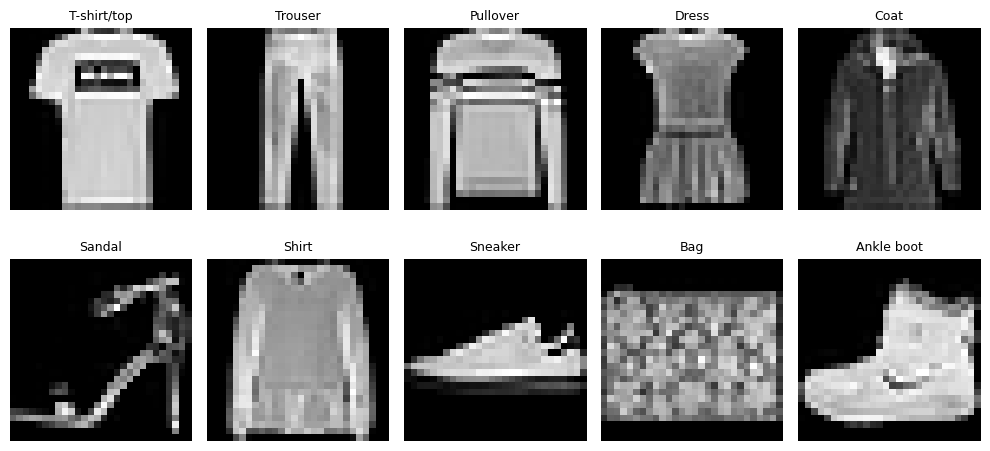

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ---------- 1. Загрузка датасета ----------
transform = transforms.Compose([transforms.ToTensor()])  # преобразуем PIL-изображения в тензоры

train_set = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# ---------- 2. Метки классов ----------
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
print("Соответствие номер-класс:")
for i, name in enumerate(classes):
    print(f"{i}: {name}")

# ---------- Визуализация примеров (по одному на каждый класс) ----------
def show_examples(dataset, classes, cols=5):
    """Показывает по одному изображению каждого класса в виде сетки."""
    rows = 2  # 10 классов -> 2 строки по 5
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5))
    axes = axes.flatten()
    
    found = {i: False for i in range(10)}
    idx = 0
    while not all(found.values()) and idx < len(dataset):
        img, label = dataset[idx]
        if not found[label]:
            found[label] = True
            ax = axes[label]
            ax.imshow(img.squeeze(), cmap='gray')
            ax.set_title(classes[label], fontsize=9)
            ax.axis('off')
        idx += 1

    plt.tight_layout()
    plt.show()

show_examples(train_set, classes)

## Задание 9. Классификация одежды

В этом задании ты обучишь логистическую регрессию для многоклассовой классификации изображений Fashion-MNIST
и замеришь качество.

1. **Подготовка данных:**
   - Используй данные, загруженные в Задании 8.
   - Преобразуй изображения в векторы признаков: каждое изображение 28×28 — в вектор длины 784.
   - Раздели данные на обучающую и тестовую выборки.

2. **Обучение модели:**
   - Обучи `LogisticRegression` из `sklearn.linear_model` на обучающей выборке.
   - Используй целевую переменную — метки классов (0–9).

3. **Оценка качества:**
   - На тестовой выборке посчитай точность (`accuracy_score` или `model.score`).
   - Построй и выведи матрицу ошибок (confusion matrix).
   - Выведи отчёт по метрикам `classification_report` из `sklearn.metrics` и проанализируй, по каким классам модель ошибается чаще всего.

c:\Users\User\Desktop\ml3\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Точность на тестовой выборке: 0.8439

Матрица ошибок (число предсказаний):
[[807   4  17  48   5   2 108   0   9   0]
 [  2 961   1  25   5   0   4   0   2   0]
 [ 19   6 735  12 131   1  86   0  10   0]
 [ 30  12  12 869  29   0  44   0   4   0]
 [  0   2 108  38 756   1  87   0   8   0]
 [  0   0   0   1   0 925   0  51   3  20]
 [129   2 129  40 106   1 568   0  25   0]
 [  0   0   0   0   0  33   0 938   0  29]
 [  7   1   6  10   3   5  21   5 942   0]
 [  0   0   0   0   0  13   0  47   2 938]]


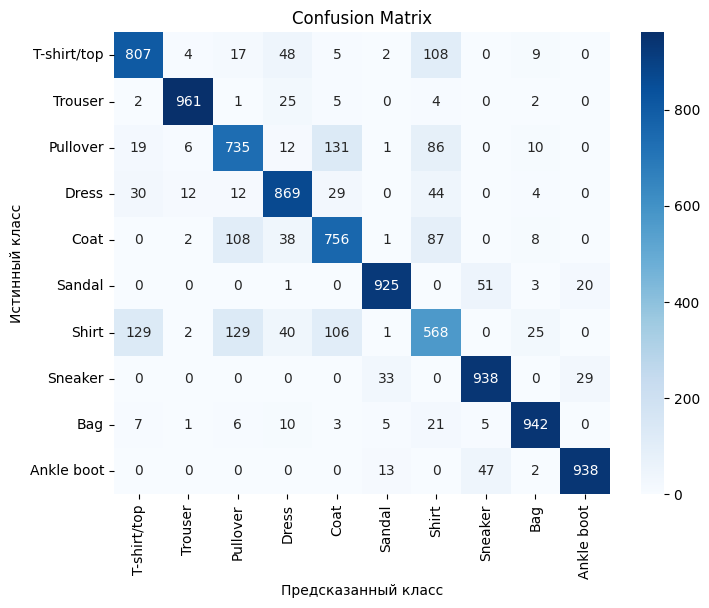


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.81      0.81      1000
     Trouser       0.97      0.96      0.97      1000
    Pullover       0.73      0.73      0.73      1000
       Dress       0.83      0.87      0.85      1000
        Coat       0.73      0.76      0.74      1000
      Sandal       0.94      0.93      0.93      1000
       Shirt       0.62      0.57      0.59      1000
     Sneaker       0.90      0.94      0.92      1000
         Bag       0.94      0.94      0.94      1000
  Ankle boot       0.95      0.94      0.94      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train = train_set.data.numpy().reshape(-1, 28*28) / 255.0
y_train = train_set.targets.numpy()

X_test = test_set.data.numpy().reshape(-1, 28*28) / 255.0
y_test = test_set.targets.numpy()

model = LogisticRegression()

model.fit(X_train, y_train)
pred = model.predict(X_test)

# Точность
acc = accuracy_score(y_test, pred)
print(f"Точность на тестовой выборке: {acc:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, pred)
print("\nМатрица ошибок (число предсказаний):")
print(cm)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Отчёт по метрикам
print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=classes))

### Бонусные задания. Нейронные сети

Один слой нейронной сети без нелинейной функции активации — это по сути линейная модель: те же веса ${w}$,
свободный член $b$ и формула ${w}^T {x} + b$. Всё, что ты делал с линейной и логистической регрессией,
укладывается в «один линейный слой». Нейросеть становится по-настоящему нелинейной, когда добавляются скрытые слои
и функции активации (ReLU, сигмоида и др.): каждый слой — линейное преобразование, активация «ломает» линейность,
и цепочка таких слоёв позволяет приближать сложные зависимости.

**PyTorch** — популярный фреймворк для машинного обучения и глубокого обучения. В нём модель задаётся как композиция
слоёв, градиенты считаются автоматически (autograd), а обучение идёт итеративно, как в градиентном спуске. PyTorch
удобен для экспериментов и исследований, его часто используют в индустрии. В этих заданиях ты попробуешь реализовать
простые нейросети на PyTorch и применить их к классификации Fashion-MNIST.

![nn](../misc/images/nn.png)

## Задание 10. Линейная регрессия на PyTorch

1. **Построй модель:**
   - Однослойная сеть на PyTorch — линейный классификатор `nn.Linear(784, 10)` без нелинейной активации (или с
     логистикой на выходе).
   - Вход — вектор признаков длины 784 (развёрнутое изображение 28×28), выход — 10 чисел (по одному на класс).

2. **Обучи модель:**
   - Используй градиентный спуск или его вариант (например, SGD/Adam через `torch.optim`).
   - В качестве функции потерь возьми кросс-энтропию (`nn.CrossEntropyLoss`).

3. **Оцени качество:**
   - На тестовой выборке замерь точность классификации.
   - Используй данные из Заданий 8–9 (векторизованные изображения и метки классов).

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),                     
    transforms.Lambda(lambda x: x.view(-1))    
])

train_set = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=1000, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset


class LinMod(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.input = input
        self.output = output
        self.l1 = nn.Linear(input, 392)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(392, 196)
        self.l3 = nn.Linear(196, output)

    def forward(self, x):
        x = self.l1(x)
        x = self.relu(x)
        x = self.l2(x)
        x = self.relu(x)
        x = self.l3(x)
        return x


In [ ]:
model = LinMod(784, 10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        # images уже имеют форму (batch, 784) благодаря transform
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}')

Epoch 1, Loss: 1.3844
Epoch 2, Loss: 0.7047
Epoch 3, Loss: 0.5843
Epoch 4, Loss: 0.5257
Epoch 5, Loss: 0.4937


In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 81.81%


Accuracy: 80.96%
Accuracy: 81.81%


## Задание 11. Нейронная сеть

1. **Усложни архитектуру:**
   - Добавь один или несколько скрытых слоёв с нелинейной активацией (например, ReLU).
   - Увеличь количество нейронов в скрытых слоях, чтобы модель могла лучше аппроксимировать зависимость между
     признаками и метками.

2. **Обучи и оцени:**
   - Обучи сеть на тех же данных Fashion-MNIST.
   - Замерь точность на тестовой выборке.
   - Сравни результат с однослойной моделью из Задания 10 (улучшилась ли точность, насколько, не возникло ли
     переобучения).

## Задание 12. Эксперименты

Попробуй разными способами повысить качество работы модели на Fashion-MNIST.

1. **Что можно менять:**
   - архитектуру сети (число слоёв, число нейронов);
   - функции активации;
   - оптимизатор и learning rate;
   - размер батча, количество эпох.

2. **Что нужно оформить:**
   - Кратко опиши, какие варианты ты попробовал.
   - Сделай небольшой вывод: что сработало лучше и почему, какие идеи тебе кажутся перспективными.